# Paper 01 — Ghanem, Sant'Anna & Wüthrich: *Selection and Parallel Trends*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/afrtrivi1120/causal-inference-papers-explainer/blob/master/papers/did/01-ghanem-santanna-wuthrich-selection-parallel-trends/simulation.ipynb)

See this folder's `README.md` for the 12-section explainer. This notebook is its runnable companion.

**What this simulation shows.** Parallel trends (PT) is a restriction on *how units select into treatment*, not a statement about trends alone. We draw one dataset under each of two scenarios with the same constant treatment effect:

- **Scenario A** — selection on time-invariant levels only (the gain-driving factor is independent of the untreated trend). PT holds; the 2×2 DiD recovers the true ATT.
- **Scenario B** — Roy-style selection where the gain-driving factor *also* moves the untreated trend. PT silently fails; 2×2 DiD is biased.

This is a single-draw illustration. The paper's claim is in expectation; one draw at a large `N` is enough to make the contrast visible.


## Setup

In [1]:
suppressPackageStartupMessages(library(tidyverse))
set.seed(20260421)

cat(sprintf('R          %s\n', paste(R.version$major, R.version$minor, sep = '.')))
cat(sprintf('tidyverse  %s\n', packageVersion('tidyverse')))


R          4.5.3


tidyverse  2.0.0


## Parameters

Large `N` keeps a single draw close to its expectation. No Monte Carlo loop.

In [2]:
N      <- 4000   # units per scenario
TAU    <- 1.5    # base treatment effect; with v ~ N(0,1) this gives P(D=1) ~ 0.93
LAMBDA <- 1.0    # spread of individual gains around TAU
GAMMA  <- 0.8    # common time effect on Y(0)
SIGMA  <- 0.5    # idiosyncratic noise SD


## Simulate and estimate

`rho` controls the correlation between the gain-driving factor `v` and the untreated trend in period 2:

- `rho = 0` — selection on `v` is independent of the untreated trend ⇒ PT holds.
- `rho = 1` — `v` drives both gains and the untreated trend ⇒ Roy selection breaks PT.

We draw once per scenario and fit the standard 2×2 DiD via `lm(y ~ treat * post)`.

In [3]:
one_draw <- function(rho) {
  alpha <- rnorm(N); v <- rnorm(N)
  y0_t1 <- alpha + rnorm(N, 0, SIGMA)
  y0_t2 <- alpha + GAMMA + rho * v + rnorm(N, 0, SIGMA)
  gain  <- TAU + LAMBDA * v
  D     <- as.integer(gain + rnorm(N, 0, 0.3) > 0)        # Roy-style selection
  y_t2  <- ifelse(D == 1, y0_t2 + gain, y0_t2)

  panel <- tibble(post  = rep(c(0L, 1L), each = N),
                  treat = rep(D, 2),
                  y     = c(y0_t1, y_t2))
  fit <- lm(y ~ treat * post, data = panel)

  list(D = D, y0_t1 = y0_t1, y0_t2 = y0_t2, y_t2 = y_t2,
       true_ATT = mean(gain[D == 1]),
       DiD      = unname(coef(fit)['treat:post']))
}

A <- one_draw(rho = 0.0)
B <- one_draw(rho = 1.0)

tibble(
  scenario = c('A: PT holds (rho=0)', 'B: Roy selection (rho=1)'),
  true_ATT = c(A$true_ATT, B$true_ATT),
  DiD      = c(A$DiD,      B$DiD),
  bias     = c(A$DiD - A$true_ATT, B$DiD - B$true_ATT)
)


scenario,true_ATT,DiD,bias
<chr>,<dbl>,<dbl>,<dbl>
A: PT holds (rho=0),1.631186,1.564422,-0.06676354
B: Roy selection (rho=1),1.647787,3.655530,2.00774333


## Diagnostic plot

Group-period means with the treated group's counterfactual `Y(0)` trend (dashed). In Scenario A the dashed line is parallel to the control trend; in Scenario B it bends, exposing the PT violation.

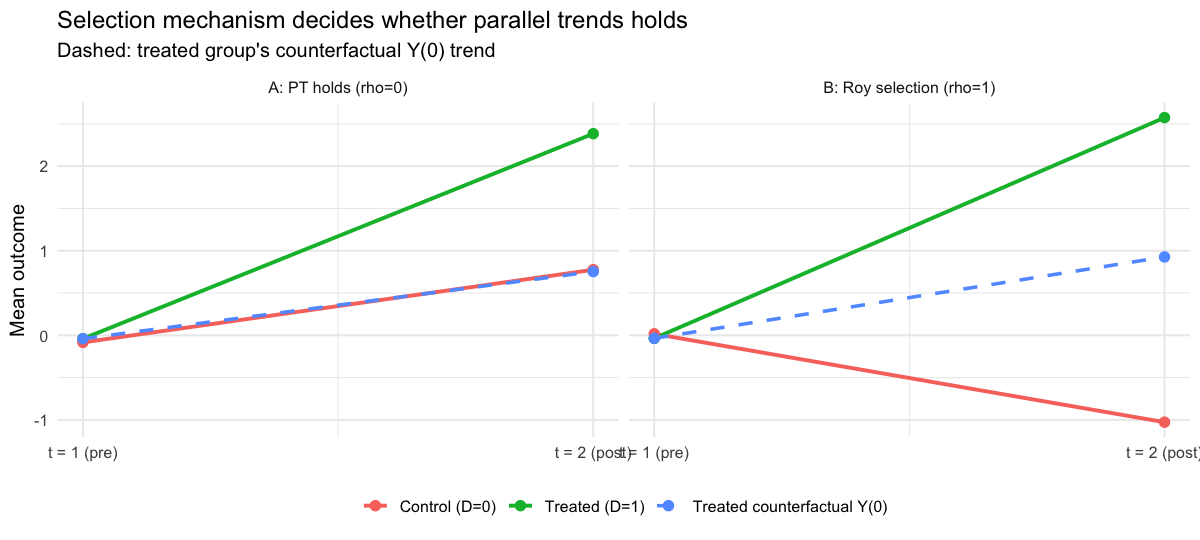

In [4]:
panel_means <- function(s, label) {
  tibble(
    scenario = label,
    period   = rep(c(1, 2), each = 2),
    group    = rep(c('Treated (D=1)', 'Control (D=0)'), 2),
    y        = c(mean(s$y0_t1[s$D == 1]), mean(s$y0_t1[s$D == 0]),
                 mean(s$y_t2[s$D == 1]),  mean(s$y_t2[s$D == 0]))
  )
}
counterfactual <- function(s, label) {
  tibble(scenario = label, period = c(1, 2),
         group = 'Treated counterfactual Y(0)',
         y     = c(mean(s$y0_t1[s$D == 1]), mean(s$y0_t2[s$D == 1])))
}

lbl_A <- 'A: PT holds (rho=0)'
lbl_B <- 'B: Roy selection (rho=1)'
plot_df <- bind_rows(panel_means(A, lbl_A),    panel_means(B, lbl_B))
cf_df   <- bind_rows(counterfactual(A, lbl_A), counterfactual(B, lbl_B))

options(repr.plot.width = 10, repr.plot.height = 4.5)

ggplot(plot_df, aes(period, y, colour = group)) +
  geom_line(linewidth = 1.1) + geom_point(size = 2.5) +
  geom_line(data = cf_df,  linewidth = 1.0, linetype = 'dashed') +
  geom_point(data = cf_df, size = 2.5) +
  scale_x_continuous(breaks = c(1, 2), labels = c('t = 1 (pre)', 't = 2 (post)')) +
  facet_wrap(~ scenario) +
  labs(title    = 'Selection mechanism decides whether parallel trends holds',
       subtitle = "Dashed: treated group's counterfactual Y(0) trend",
       x = NULL, y = 'Mean outcome', colour = NULL) +
  theme_minimal(base_size = 12) +
  theme(legend.position = 'bottom')


## Punchline

- **Scenario A.** The gain-driving factor `v` is independent of the untreated trend, so the dashed line is parallel to the control trend and DiD recovers the true ATT.
- **Scenario B.** The same `v` that drives gains also moves the untreated trend. The treated group's `Y(0)` trajectory is steeper than the control's, the dashed line is no longer parallel, and DiD overstates the ATT.

This is one draw; the paper's claim is in expectation. But notice the bias decomposition: `bias ≈ rho · (E[v | D=1] − E[v | D=0])`. Both `rho > 0` *and* selection correlated with `v` are required — remove either ingredient and DiD is unbiased. That joint dependence is exactly Ghanem, Sant'Anna & Wüthrich's point: parallel trends is a property of the *interaction* between the selection rule and the dynamics of `Y(0)`, not of either in isolation.
